# Notebook 02 - Transformation Pipeline & Dataset Loader Validation

This notebook validates the image preprocessing and data loading pipeline used during model training and evaluation.

It loads the transformation configuration from `configs/transforms_v1.yaml` and constructs the training and evaluation transform pipelines using the utilities defined in `src/data/transforms.py`. The training pipeline includes stochastic augmentations such as random cropping, flipping, rotation, and color jitter to improve model robustness, while the evaluation pipeline applies deterministic preprocessing to ensure consistent validation and test results.

The notebook then instantiates the reusable `ImageDataset` loader implemented in `src/data/dataset_loader.py`, which reads the split CSV files and loads images from disk while applying the configured transforms.

Several checks are performed to verify that the pipeline functions correctly:
- confirm dataset sizes
- verify that images are converted to tensors with shape `(3, 224, 224)`
- visualize multiple augmented versions of the same image
- run a small `DataLoader` batch test

The notebook also saves a visualization of augmented samples to `reports/figures/sample_augmented_images.png`.

Completing this notebook confirms that the **data loading and augmentation pipeline is fully operational and ready for model training.**

In [2]:
from pathlib import Path
import sys
import json
import random

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "transforms_v1.yaml"
SPLIT_DIR = PROJECT_ROOT / "data" / "splits" / "split_v1"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("CONFIG:", CONFIG_PATH)
print("SPLITS:", SPLIT_DIR)

CONFIG: f:\Projects\AnimalClassification\configs\transforms_v1.yaml
SPLITS: f:\Projects\AnimalClassification\data\splits\split_v1


In [3]:
from src.data.transforms import load_transforms_config, get_train_transforms, get_eval_transforms

cfg = load_transforms_config(CONFIG_PATH)
train_tf = get_train_transforms(cfg)
eval_tf = get_eval_transforms(cfg)

cfg

{'image_size': 224,
 'resize_size': 256,
 'normalize': {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]},
 'train_transforms': [{'name': 'random_resized_crop',
   'params': {'size': 224, 'scale': [0.7, 1.0], 'ratio': [0.75, 1.3333]}},
  {'name': 'random_horizontal_flip', 'params': {'p': 0.5}},
  {'name': 'random_rotation', 'params': {'degrees': 15}},
  {'name': 'color_jitter',
   'params': {'brightness': 0.2,
    'contrast': 0.2,
    'saturation': 0.2,
    'hue': 0.05}},
  {'name': 'to_tensor', 'params': {}},
  {'name': 'normalize', 'params': {}}],
 'eval_transforms': [{'name': 'resize', 'params': {'size': 256}},
  {'name': 'center_crop', 'params': {'size': 224}},
  {'name': 'to_tensor', 'params': {}},
  {'name': 'normalize', 'params': {}}]}

In [4]:
classes_path = SPLIT_DIR / "classes.json"
classes_to_idx = json.loads(classes_path.read_text(encoding="utf-8"))
idx_to_classes = {v: k for k, v in classes_to_idx.items()}

classes_to_idx

{'cats': 0, 'dogs': 1, 'wildlife': 2}

In [5]:
from src.data.dataset_loader import ImageDataset

train_ds = ImageDataset(SPLIT_DIR / "train.csv", transform=train_tf, classes_to_idx=classes_to_idx)
val_ds = ImageDataset(SPLIT_DIR / "val.csv", transform=eval_tf, classes_to_idx=classes_to_idx)

len(train_ds), len(val_ds)

(50127, 6266)

In [6]:
x, y = train_ds[0]
x.shape, y, idx_to_classes[y]

(torch.Size([3, 224, 224]), 2, 'wildlife')

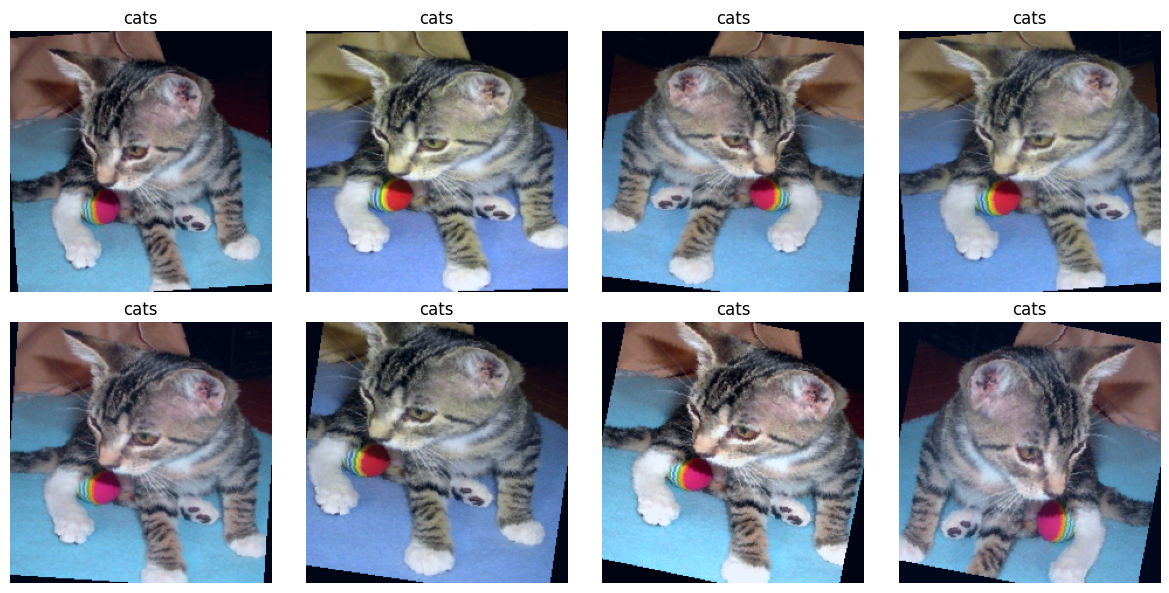

WindowsPath('f:/Projects/AnimalClassification/reports/figures/sample_augmented_images.png')

In [7]:
import pandas as pd
from PIL import Image

train_df = pd.read_csv(SPLIT_DIR / "train.csv")
row = train_df.sample(1, random_state=42).iloc[0]
img = Image.open(row["filepath"]).convert("RGB")
label = row["label"]

n = 8
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(12, 3 * rows))
for i in range(n):
    x = train_tf(img)
    vis = x.permute(1, 2, 0).numpy()
    vis = (vis - vis.min()) / (vis.max() - vis.min() + 1e-8)
    ax = plt.subplot(rows, cols, i + 1)
    ax.imshow(vis)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
out_path = FIGURES_DIR / "sample_augmented_images.png"
plt.savefig(out_path, dpi=150)
plt.show()

out_path

In [8]:
loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)

xb, yb = next(iter(loader))
xb.shape, yb.shape

(torch.Size([16, 3, 224, 224]), torch.Size([16]))